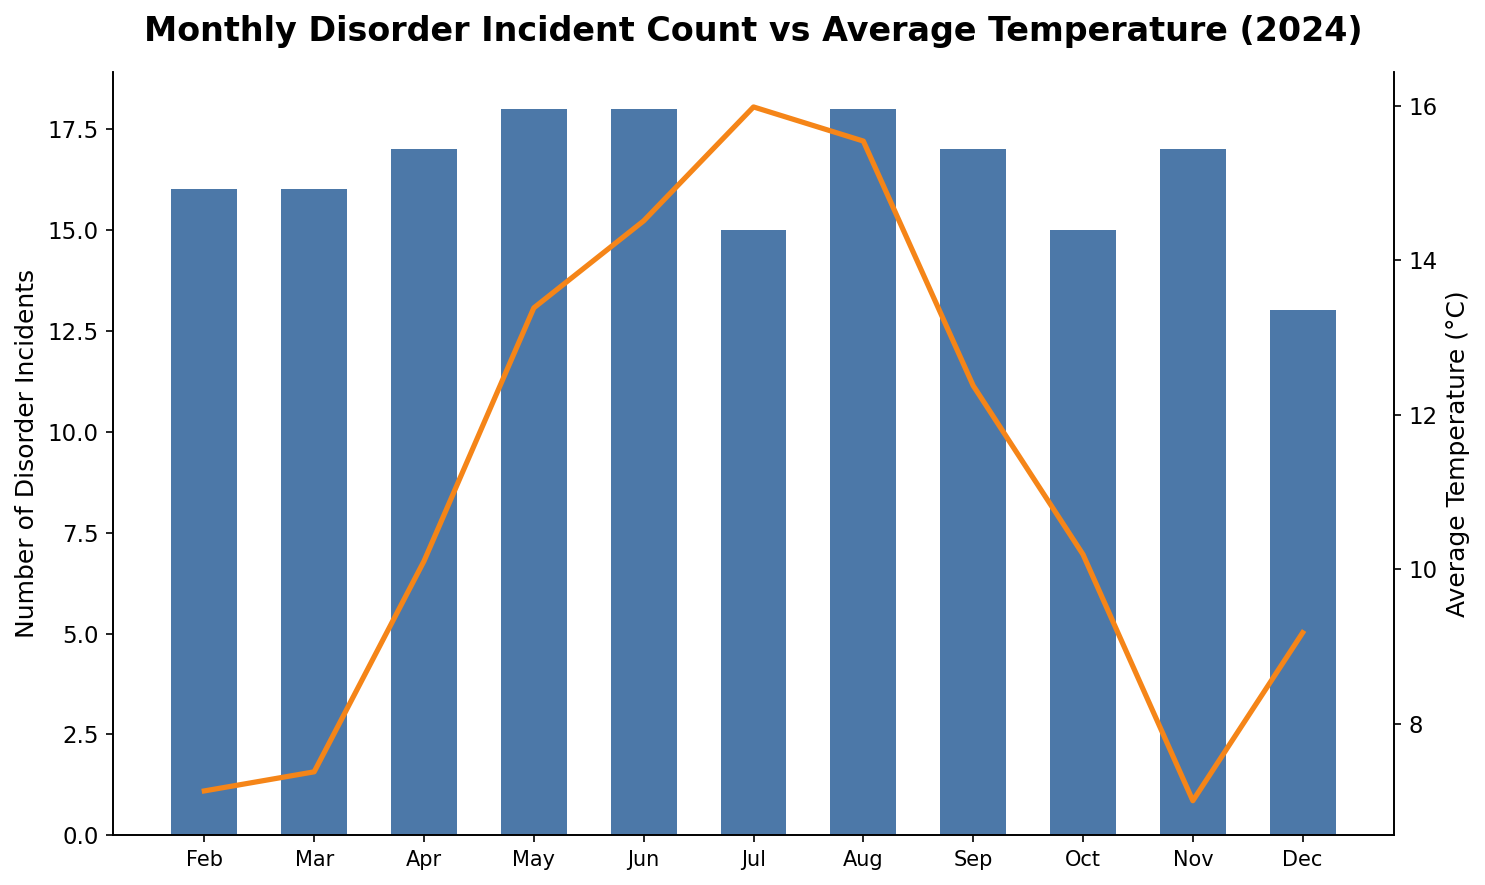

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
crime_df = pd.read_csv("final_cleaned_crime_dataset.csv")
weather_df = pd.read_excel("weather clean.xlsx")

# -------------------------------
# Clean station names
# -------------------------------
crime_df["station"] = crime_df["station"].replace({
    "Kings Cross St Pancras": "Kings Cross"
})

weather_df.rename(columns={"Stations ": "station"}, inplace=True)

weather_df["station"] = weather_df["station"].replace({
    "London Kings Cross": "Kings Cross",
    "Newcastle": "Newcastle Central",
    "Edinburgh": "Edinburgh Waverley"
})

# -------------------------------
# Format dates
# -------------------------------
crime_df["date"] = pd.to_datetime(crime_df["date"])
weather_df["Date"] = pd.to_datetime(weather_df["Date"])

weather_df["date"] = weather_df["Date"].dt.to_period("M").dt.to_timestamp()

# -------------------------------
# Convert temperature to Celsius
# -------------------------------
weather_df["temperature_avg"] = (weather_df["temperature_avg"] - 32) * 5 / 9

# -------------------------------
# Filter disorder
# -------------------------------
crime_disorder = crime_df[crime_df["disorder_flag"] == 1]

# -------------------------------
# Aggregate monthly
# -------------------------------
monthly_disorder = crime_disorder.groupby("date").size().reset_index(name="disorder_count")
monthly_temp = weather_df.groupby("date")["temperature_avg"].mean().reset_index(name="avg_temperature_c")

# Merge
merged_df = pd.merge(monthly_disorder, monthly_temp, on="date", how="inner")
merged_df = merged_df.sort_values("date")

# -------------------------------
# Clean month labels (NO YEAR)
# -------------------------------
merged_df["month_label"] = merged_df["date"].dt.strftime("%b")

# -------------------------------
# Plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Bars (crime)
ax1.bar(
    merged_df["month_label"],
    merged_df["disorder_count"],
    color="#4C78A8",
    width=0.6
)

ax1.set_ylabel("Number of Disorder Incidents", fontsize=12)
ax1.tick_params(axis="y", labelsize=11)
ax1.spines["top"].set_visible(False)
ax1.grid(False)

# Line (temperature)
ax2 = ax1.twinx()
ax2.plot(
    merged_df["month_label"],
    merged_df["avg_temperature_c"],
    color="#F58518",
    linewidth=2.5
)

ax2.set_ylabel("Average Temperature (°C)", fontsize=12)
ax2.tick_params(axis="y", labelsize=11)
ax2.spines["top"].set_visible(False)
ax2.grid(False)

# Title with year moved here
ax1.set_title(
    "Monthly Disorder Incident Count vs Average Temperature (2024)",
    fontsize=16,
    weight="bold",
    pad=15
)

# Final layout
plt.tight_layout()
plt.savefig("graph3_final_clean_minimal.png", dpi=300, bbox_inches="tight")
plt.show()

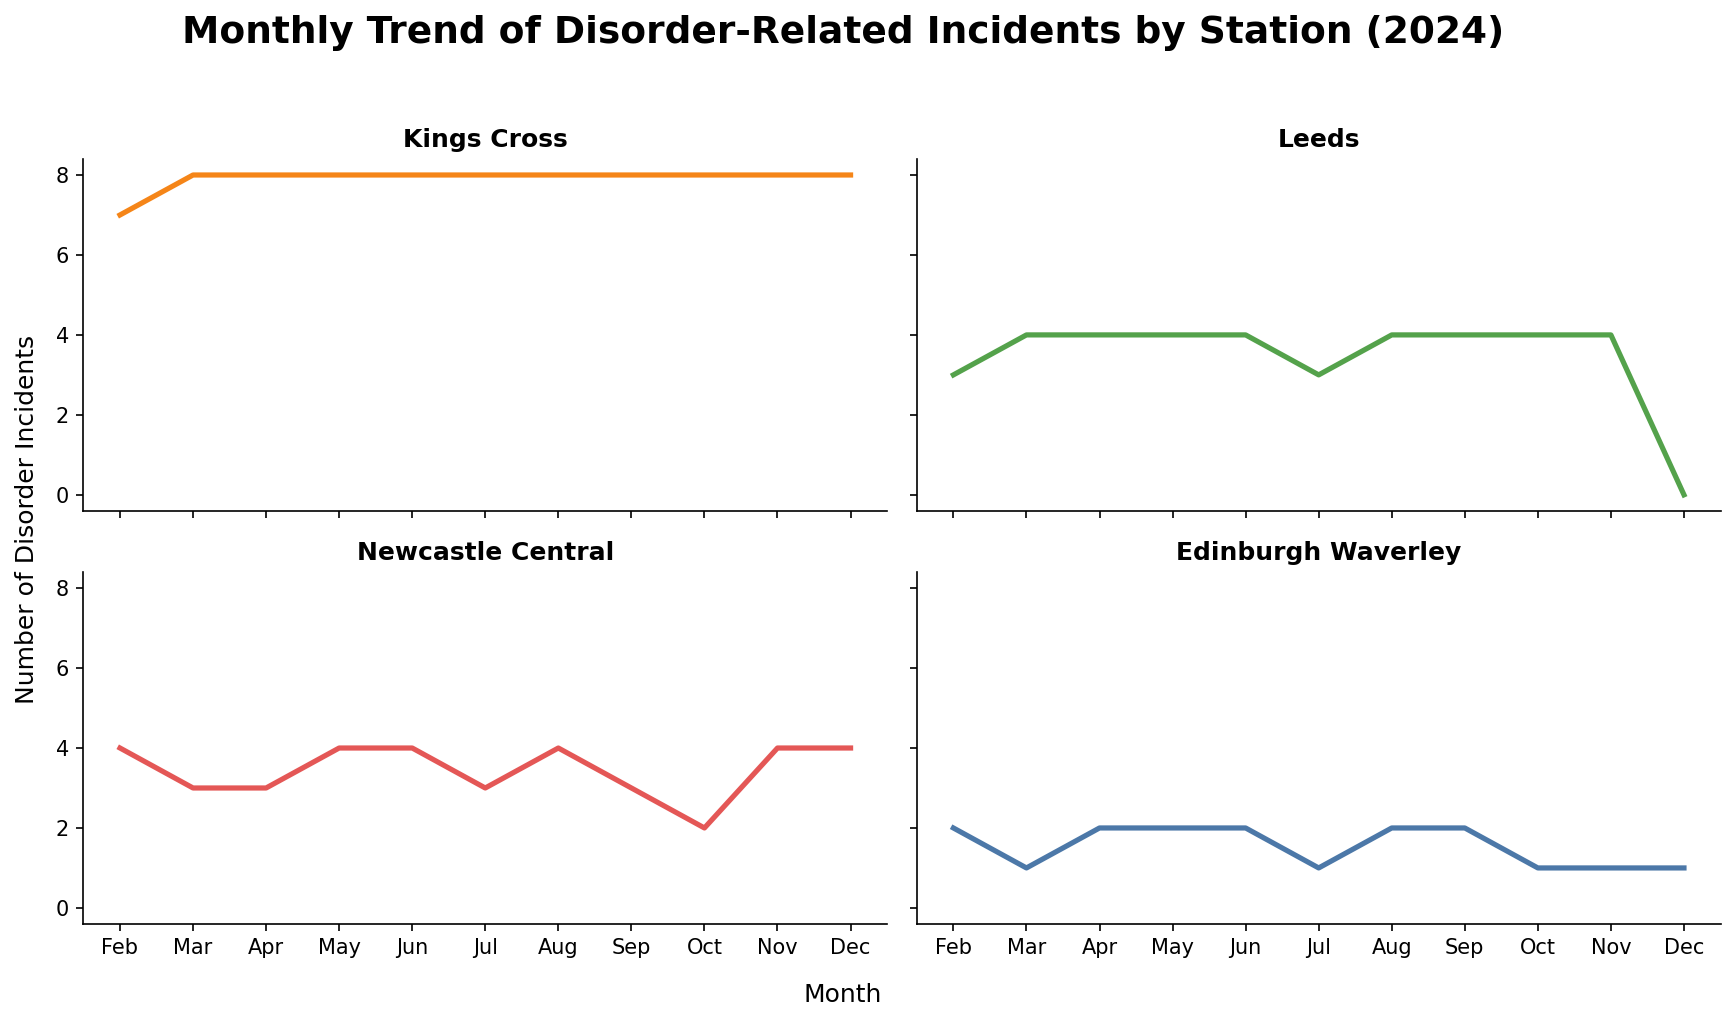

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("final_cleaned_crime_dataset.csv")

# Ensure date column is in datetime format
df["date"] = pd.to_datetime(df["date"])

# Combine Kings Cross St Pancras into Kings Cross
df["station"] = df["station"].replace({
    "Kings Cross St Pancras": "Kings Cross"
})

# Keep only disorder-related incidents
df_disorder = df[df["disorder_flag"] == 1].copy()

# Aggregate disorder incidents by month and station
monthly_station_disorder = (
    df_disorder.groupby(["date", "station"])
    .size()
    .reset_index(name="disorder_count")
)

# Create month labels
monthly_station_disorder["month_label"] = monthly_station_disorder["date"].dt.strftime("%b")

# Pivot and fill missing months with 0
plot_data = monthly_station_disorder.pivot(
    index="month_label",
    columns="station",
    values="disorder_count"
).fillna(0)

# Keep months in correct order
month_order = ["Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plot_data = plot_data.reindex(month_order)

# Define station order and colours
stations = ["Kings Cross", "Leeds", "Newcastle Central", "Edinburgh Waverley"]
colors = {
    "Kings Cross": "#F58518",
    "Leeds": "#54A24B",
    "Newcastle Central": "#E45756",
    "Edinburgh Waverley": "#4C78A8"
}

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=150, sharex=True, sharey=True)
axes = axes.flatten()

for ax, station in zip(axes, stations):
    ax.plot(
        plot_data.index,
        plot_data[station],
        color=colors[station],
        linewidth=2.5
    )

    ax.set_title(station, fontsize=12, weight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

# Shared title
fig.suptitle("Monthly Trend of Disorder-Related Incidents by Station (2024)", fontsize=18, weight="bold", y=0.98)

# Shared axis labels
fig.text(0.04, 0.5, "Number of Disorder Incidents", va="center", rotation="vertical", fontsize=12)
fig.text(0.5, 0.04, "Month", ha="center", fontsize=12)

plt.tight_layout(rect=[0.05, 0.06, 1, 0.95])
plt.savefig("graph2_small_multiples_final.png", dpi=300, bbox_inches="tight")
plt.show()

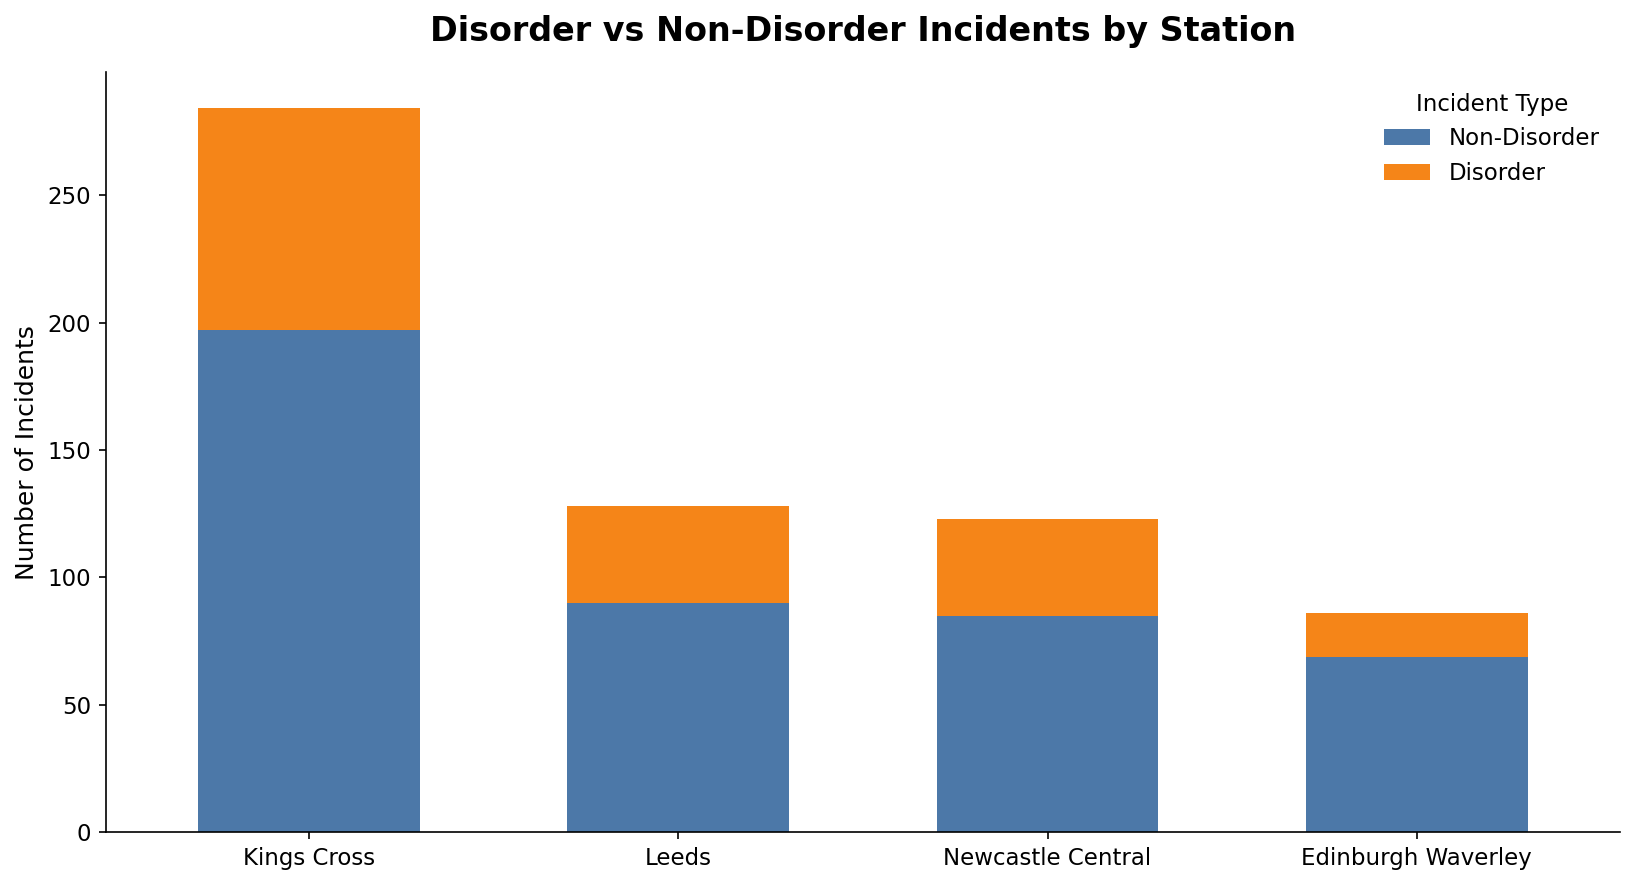

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the cleaned crime dataset
df = pd.read_csv("final_cleaned_crime_dataset.csv")

# Combine Kings Cross St Pancras into Kings Cross
df["station"] = df["station"].replace({
    "Kings Cross St Pancras": "Kings Cross"
})

# Group data
station_disorder_counts = df.groupby(["station", "disorder_flag"]).size().unstack(fill_value=0)
station_disorder_counts.columns = ["Non-Disorder", "Disorder"]

# Sort by total incidents
station_disorder_counts["Total"] = station_disorder_counts.sum(axis=1)
station_disorder_counts = station_disorder_counts.sort_values("Total", ascending=False)
plot_data = station_disorder_counts.drop(columns="Total")

# Create figure
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

# Plot bars
plot_data.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#4C78A8", "#F58518"],
    width=0.6,
    edgecolor="none"
)

# Title and labels
ax.set_title("Disorder vs Non-Disorder Incidents by Station", fontsize=16, weight="bold", pad=15)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_xlabel("")

# Clean look
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 🔑 FIX: Force perfect horizontal, centered labels
ax.set_xticks(np.arange(len(plot_data.index)))
ax.set_xticklabels(plot_data.index, rotation=0, ha="center", fontsize=11)

# Y-axis formatting
ax.tick_params(axis="y", labelsize=11)

# Legend
ax.legend(
    title="Incident Type",
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    loc="upper right"
)

# Layout
plt.tight_layout()

# Save
plt.savefig("graph1_final_perfect.png", dpi=300, bbox_inches="tight")

plt.show()